In [4]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

device="cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [5]:


RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2" /"images"  # adjust if your JPGs landed one folder deeper
DATA_ROOT = Path("galaxy_data")        # train/val/test subfolders get created here
LABELS_URL = "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"

# --- Download via Kaggle API (run once; same as Week 1) ---
from google.colab import files
files.upload()  # select kaggle.json
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!pip -q install kaggle
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images
!unzip -q -o galaxy-zoo-2-images.zip -d {RAW_ROOT}
!unzip -q -o {RAW_ROOT}/images_gz2.zip -d {IMAGES_DIR}
!wget -q -O {RAW_ROOT}/gz2_hart16.csv.gz {LABELS_URL}
!gunzip -f {RAW_ROOT}/gz2_hart16.csv.gz

print("RAW_ROOT   =", RAW_ROOT)
print("IMAGES_DIR =", IMAGES_DIR)
print("DATA_ROOT  =", DATA_ROOT)



Saving kaggle(1).json to kaggle(1).json
cp: cannot stat 'kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [03:03<00:00, 17.8MB/s]

unzip:  cannot find or open galaxy_raw/images_gz2.zip, galaxy_raw/images_gz2.zip.zip or galaxy_raw/images_gz2.zip.ZIP.
RAW_ROOT   = galaxy_raw
IMAGES_DIR = galaxy_raw/images_gz2/images
DATA_ROOT  = galaxy_data


In [23]:
import os
from pathlib import Path

import pandas as pd
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader


def high_level_label(gz2_class):
    if not isinstance(gz2_class, str) or gz2_class == "A":
        return None

    if gz2_class.startswith("E"):
        return "elliptical"

    if gz2_class.startswith("SB"):
        return "spiral_barred"

    if gz2_class.startswith("S"):
        return "spiral"

    return None


def load_labeled_table(mapping_csv, labels_csv):
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv)

    if "dr7objid" in labels.columns:
        labels = labels.rename(columns={"dr7objid": "objid"})

    df = mapping.merge(
        labels[["objid", "gz2_class"]],
        on="objid",
        how="inner"
    )

    df["label"] = df["gz2_class"].map(high_level_label)

    return (
        df.dropna(subset=["label"])
          .reset_index(drop=True)
    )


def _link_image(src, dst):
    if dst.exists():
        return False

    dst.parent.mkdir(parents=True, exist_ok=True)

    try:
        os.symlink(Path(src).resolve(), dst)
    except OSError:
        import shutil
        shutil.copy2(src, dst)

    return True


def build_split_imagefolder_layout(
    images_dir,
    df,
    out_root,
    per_class=200,
    train_frac=0.70,
    val_frac=0.15,
    test_frac=0.15,
    seed=42,
):
    images_dir = Path(images_dir)
    out_root = Path(out_root)

    for label in sorted(df["label"].unique()):
        rows = (
            df[df["label"] == label]
            .sample(frac=1, random_state=seed)
            .reset_index(drop=True)
        )

        if len(rows) > per_class:
            rows = rows.head(per_class)

        n = len(rows)

        n_train = int(train_frac * n)
        n_val = int(val_frac * n)

        splits = {
            "train": rows.iloc[:n_train],
            "val": rows.iloc[n_train:n_train + n_val],
            "test": rows.iloc[n_train + n_val:],
        }

        for split_name, split_rows in splits.items():
            for _, row in split_rows.iterrows():
                src = images_dir / f"{int(row.asset_id)}.jpg"
                dst = (
                    out_root
                    / split_name
                    / label
                    / f"{int(row.asset_id)}.jpg"
                )

                if src.exists():
                    _link_image(src, dst)


# -----------------------------
# Build dataset folders
# -----------------------------

PER_CLASS = 2000

df = load_labeled_table(
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
)

build_split_imagefolder_layout(
    IMAGES_DIR,
    df,
    DATA_ROOT,
    per_class=PER_CLASS,
)

print(df["label"].value_counts())


# -----------------------------
# Transforms
# -----------------------------

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    ),
])


# -----------------------------
# Datasets
# -----------------------------

train_ds = ImageFolder(
    root=DATA_ROOT / "train",
    transform=transform,
)

val_ds = ImageFolder(
    root=DATA_ROOT / "val",
    transform=transform,
)

test_ds = ImageFolder(
    root=DATA_ROOT / "test",
    transform=transform,
)


# -----------------------------
# DataLoaders
# -----------------------------

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)


# -----------------------------
# Info
# -----------------------------

num_classes = len(train_ds.classes)

print("classes     :", train_ds.classes)
print("class_to_idx:", train_ds.class_to_idx)
print("num_classes :", num_classes)

print("train size :", len(train_ds))
print("val size   :", len(val_ds))
print("test size  :", len(test_ds))

label
elliptical       97670
spiral           95849
spiral_barred    45581
Name: count, dtype: int64
classes     : ['elliptical', 'spiral', 'spiral_barred']
class_to_idx: {'elliptical': 0, 'spiral': 1, 'spiral_barred': 2}
num_classes : 3
train size : 4590
val size   : 1079
test size  : 1080


In [24]:
def loader_to_numpy(loader):
  xs,ys=[],[]
  for images,labels in loader:
    flat=images.flatten(start_dim=1)
    xs.append(flat.numpy())
    ys.append(labels.numpy())
  return np.concatenate(xs,axis=0),np.concatenate(ys,axis=0)


x_train,y_train=loader_to_numpy(train_loader)
x_test,y_test=loader_to_numpy(test_loader)
print("x_train:" ,x_train.shape,"y_train",y_train.shape)
print('x_test:',x_test.shape,'y_test:',y_test.shape)
assert x_train.shape[1]==3*64*64



x_train: (4590, 12288) y_train (4590,)
x_test: (1080, 12288) y_test: (1080,)


In [25]:
from pathlib import Path
import pandas as pd

mapping = pd.read_csv(RAW_ROOT / "gz2_filename_mapping.csv")
labels = pd.read_csv(RAW_ROOT / "gz2_hart16.csv")

print("MAPPING COLUMNS:")
print(mapping.columns.tolist())

print("\nLABELS COLUMNS:")
print(labels.columns.tolist())

print("\nMAPPING HEAD:")
print(mapping.head())

print("\nLABELS HEAD:")
print(labels.head())

print("\nFIRST 10 IMAGE FILES:")
for f in list(Path(IMAGES_DIR).iterdir())[:10]:
    print(f.name)

MAPPING COLUMNS:
['objid', 'sample', 'asset_id']

LABELS COLUMNS:
['dr7objid', 'ra', 'dec', 'rastring', 'decstring', 'sample', 'gz2_class', 'total_classifications', 'total_votes', 't01_smooth_or_features_a01_smooth_count', 't01_smooth_or_features_a01_smooth_weight', 't01_smooth_or_features_a01_smooth_fraction', 't01_smooth_or_features_a01_smooth_weighted_fraction', 't01_smooth_or_features_a01_smooth_debiased', 't01_smooth_or_features_a01_smooth_flag', 't01_smooth_or_features_a02_features_or_disk_count', 't01_smooth_or_features_a02_features_or_disk_weight', 't01_smooth_or_features_a02_features_or_disk_fraction', 't01_smooth_or_features_a02_features_or_disk_weighted_fraction', 't01_smooth_or_features_a02_features_or_disk_debiased', 't01_smooth_or_features_a02_features_or_disk_flag', 't01_smooth_or_features_a03_star_or_artifact_count', 't01_smooth_or_features_a03_star_or_artifact_weight', 't01_smooth_or_features_a03_star_or_artifact_fraction', 't01_smooth_or_features_a03_star_or_artifact_

In [26]:
from pathlib import Path

# Keep only rows whose image file actually exists
df = load_labeled_table(
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
)

df = df[
    df["asset_id"].apply(
        lambda x: (Path(IMAGES_DIR) / f"{int(x)}.jpg").exists()
    )
].reset_index(drop=True)

print("Rows with images:", len(df))
print(df["label"].value_counts())

# Build train/val/test folders
build_split_imagefolder_layout(
    IMAGES_DIR,
    df,
    DATA_ROOT,
    per_class=200,
)

print("\nDATA_ROOT exists:", Path(DATA_ROOT).exists())

if Path(DATA_ROOT).exists():
    for p in Path(DATA_ROOT).iterdir():
        print(p)

Rows with images: 239029
label
elliptical       97643
spiral           95818
spiral_barred    45568
Name: count, dtype: int64

DATA_ROOT exists: True
galaxy_data/train
galaxy_data/val
galaxy_data/test


In [27]:
from sklearn.dummy import DummyClassifier

dummy=DummyClassifier(strategy="most_frequent").fit(x_train,y_train)
majority_acc=dummy.score(x_test,y_test)
print(f"Random-guess accuracy:{1/num_classes:.3f}")
print(f"Majority-class accuracy:{majority_acc:.3f}")



Random-guess accuracy:0.333
Majority-class accuracy:0.333


In [28]:

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5).fit(x_train, y_train)
knn_acc = knn.score(x_test, y_test)
print(f"KNN (k=5) test accuracy : {knn_acc:.3f}")

KNN (k=5) test accuracy : 0.473


In [29]:

from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000).fit(x_train, y_train)
logreg_acc = logreg.score(x_test, y_test)
print(f"Logistic Regression test accuracy : {logreg_acc:.3f}")

Logistic Regression test accuracy : 0.498


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:

results = {
    "random_guess":   1 / num_classes,
    "majority_class": majority_acc,
    "knn_k5":         knn_acc,
    "logistic_reg":   logreg_acc,
}
print(pd.Series(results).round(3).to_string())
best = max(results, key=results.get)
print(f"\nBaseline to beat in Week 3: {results[best]:.3f}  (from {best})")

random_guess      0.333
majority_class    0.333
knn_k5            0.473
logistic_reg      0.498

Baseline to beat in Week 3: 0.498  (from logistic_reg)


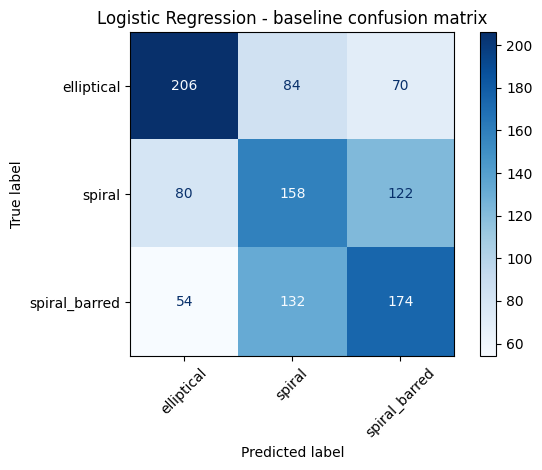

In [31]:


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = logreg.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=train_ds.classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Logistic Regression - baseline confusion matrix")
plt.tight_layout()
plt.show()



In [34]:

class GalaxyMLP(nn.Module):
    def __init__(self, in_features=3 * 64 * 64, hidden=128, num_classes=3):
        super().__init__()                        # MUST be first
        self.flatten = nn.Flatten()               # (B,3,64,64) -> (B,12288)
        self.fc1 = nn.Linear(in_features, hidden)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden, num_classes) # outputs raw logits

    def forward(self, x):                          # x: (B, 3, 64, 64)
        x = self.flatten(x)                        # (B, 12288)
        x = self.relu(self.fc1(x))                 # (B, 128)
        return self.fc2(x)                         # (B, num_classes)

In [35]:


model = GalaxyMLP(num_classes=num_classes).to(device)
print("Model is on:", next(model.parameters()).device)

print(model)
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters     : {total:,}")
print(f"Trainable parameters : {trainable:,}")

images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

logits = model(images)
print("input  :", images.shape)
print("logits :", logits.shape)   # (32, num_classes)
assert logits.shape == (images.shape[0], num_classes)



criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
print(criterion)
print(optimizer)



Model is on: cuda:0
GalaxyMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=12288, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)

Total parameters     : 1,573,379
Trainable parameters : 1,573,379
input  : torch.Size([32, 3, 64, 64])
logits : torch.Size([32, 3])
CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [36]:

import math

loss = criterion(logits, labels)
print(f"loss            : {loss.item():.4f}")
print(f"ln(num_classes) : {math.log(num_classes):.4f}   <- expected ballpark")

loss            : 1.0911
ln(num_classes) : 1.0986   <- expected ballpark


In [37]:
model.train()
loss_before = criterion(model(images), labels)

optimizer.zero_grad()   # 1. clear old gradients
loss_before.backward()  # 2. backpropagation
optimizer.step()        # 3. update weights

loss_after = criterion(model(images), labels)
print(f"loss before step : {loss_before.item():.4f}")
print(f"loss after  step : {loss_after.item():.4f}")
print("decreased!" if loss_after < loss_before else "did not decrease - check lr / setup")

loss before step : 1.0911
loss after  step : 10.4265
did not decrease - check lr / setup


In [38]:


for hidden in (64, 128, 256, 512):
    m = GalaxyMLP(hidden=hidden, num_classes=num_classes)
    n = sum(p.numel() for p in m.parameters())
    print(f"hidden={hidden:4d}  ->  {n:,} parameters")



hidden=  64  ->  786,691 parameters
hidden= 128  ->  1,573,379 parameters
hidden= 256  ->  3,146,755 parameters
hidden= 512  ->  6,293,507 parameters
